<a href="https://colab.research.google.com/github/leejungp2/dl-study/blob/main/260607_06_pytorch_transfer_learning_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. PyTorch 전이 학습 / PyTorch Transfer Learning

> 185. Github에서 피자, 스테이크, 초밥 이미지 데이터 다운로드하기 / Downloading Pizza, Steak, Sushi Image Data from Github  

### 전이 학습이란?

- **전이 학습(Transfer Learning)**은  
  한 모델이 다른 데이터셋에서 학습한 **파라미터(parameters)**를 가져와  
  우리가 해결하려는 문제에 적용하는 것을 의미함

- **사전 학습 모델(Pretrained model)**  
  = **파운데이션 모델(Foundation models)**

In [ ]:
import torch
import torchvision

print(torch.__version__) # want 1.12+
print(torchvision.__version__) # want 0.13+

2.11.0+cu128
0.26.0+cu128


In [ ]:
# 최신 API를 사용하기 위해 torch 1.12 이상, torchvision 0.13 이상이 필요함
try:
    import torch        # PyTorch 라이브러리 불러오기
    import torchvision  # 컴퓨터 비전용 PyTorch 라이브러리 불러오기

    # torch 버전의 두 번째 숫자(minor version)가 12 이상인지 확인
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"

    # torchvision 버전의 두 번째 숫자(minor version)가 13 이상인지 확인
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"

    # 현재 설치된 torch 버전 출력
    print(f"torch version: {torch.__version__}")

    # 현재 설치된 torchvision 버전 출력
    print(f"torchvision version: {torchvision.__version__}")

except:
    # torch 또는 torchvision 버전이 요구 조건을 만족하지 않을 경우 안내 메시지 출력
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")

    # 요구 조건을 만족하는 nightly 버전의 torch와 torchvision 설치
    !pip3 install -U --pre torch torchvision --extra-index-url https://download.pytorch.org/whl/nightly/cu113

    import torch        # 설치 후 PyTorch 다시 불러오기
    import torchvision  # 설치 후 torchvision 다시 불러오기

    # 설치 후 torch 버전 출력
    print(f"torch version: {torch.__version__}")

    # 설치 후 torchvision 버전 출력
    print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/nightly/cu113
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.8/200.8 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


Now we've got the versions of torch and torchvision, we're after, let's import the code we've written in previous sections so that we don't have to write it all again.

In [ ]:
# 일반적으로 사용할 라이브러리 불러오기
import matplotlib.pyplot as plt  # 그래프 및 이미지 시각화를 위한 라이브러리
import torch                     # PyTorch 라이브러리
import torchvision               # 컴퓨터 비전용 PyTorch 라이브러리

from torch import nn              # 신경망 모듈을 만들기 위한 torch.nn 불러오기
from torchvision import transforms # 이미지 변환(transform)을 위한 모듈 불러오기

# torchinfo를 불러오고, 없으면 설치하기
try:
    from torchinfo import summary  # 모델 구조 요약을 출력하기 위한 summary 함수 불러오기

except:
    # torchinfo가 설치되어 있지 않을 경우 안내 메시지 출력
    print("[INFO] Couldn't find torchinfo... installing it.")

    # torchinfo 설치
    !pip install -q torchinfo

    # 설치 후 summary 함수 다시 불러오기
    from torchinfo import summary

# going_modular 디렉토리를 불러오고, 없으면 GitHub에서 다운로드하기
try:
    # 직접 만든 모듈에서 데이터 준비 함수와 학습 엔진 불러오기
    from going_modular.going_modular import data_setup, engine

except:
    # going_modular 스크립트가 없을 경우 안내 메시지 출력
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")

    # PyTorch Deep Learning GitHub 저장소 복제
    !git clone https://github.com/mrdbourke/pytorch-deep-learning

    # 복제한 저장소 안의 going_modular 디렉토리를 현재 작업 디렉토리로 이동
    !mv pytorch-deep-learning/going_modular .

    # 더 이상 필요 없는 복제 저장소 삭제
    !rm -rf pytorch-deep-learning

    # 다운로드 후 데이터 준비 함수와 학습 엔진 다시 불러오기
    from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 19.49 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [ ]:
# 장치에 구애받지 않는 코드 설정
device = "cuda" if torch.cuda.is_available() else "cpu"  # CUDA 사용 가능 시 GPU(cuda), 아니면 CPU 사용

# 설정된 장치 확인
device

'cuda'

## 1. 데이터 가져오기 / Get data

전이 학습 모델을 만들기 위해 **피자(pizza), 스테이크(steak), 초밥(sushi)** 데이터가 필요함

In [ ]:
import os       # 파일 삭제 등 운영체제 관련 기능 사용
import zipfile  # zip 파일 압축 해제 기능 사용

from pathlib import Path  # 파일 및 디렉토리 경로를 객체 형태로 다루기 위해 사용

import requests  # URL에서 데이터를 다운로드하기 위해 사용

# 데이터 저장 경로 설정
data_path = Path("data/")  # 전체 데이터가 저장될 상위 디렉토리 경로

# 이미지 데이터가 저장될 경로 설정
image_path = data_path / "pizza_steak_sushi"  # Food101 데이터셋 일부 클래스 이미지 저장 경로

# 이미지 폴더가 이미 존재하는 경우, 다시 다운로드하지 않음
if image_path.is_dir():
  print(f"{image_path} directory exists, skipping re-download.")

# 이미지 폴더가 없는 경우, 데이터를 다운로드하고 준비함
else:
  print(f"Did not find {image_path}, downloading it...")

  # 이미지 데이터를 저장할 디렉토리 생성
  image_path.mkdir(parents=True, exist_ok=True)

  # 피자, 스테이크, 초밥 데이터 다운로드
  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    # GitHub에 있는 pizza_steak_sushi.zip 파일 요청
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")

    print("Downloading pizza, steak, sushi data...")

    # 다운로드한 zip 파일 내용을 로컬 파일로 저장
    f.write(request.content)

  # 피자, 스테이크, 초밥 데이터 압축 해제
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data...")

    # zip 파일 내용을 image_path 경로에 모두 압축 해제
    zip_ref.extractall(image_path)

  # 압축 해제가 끝난 후 zip 파일 삭제
  os.remove(data_path / "pizza_steak_sushi.zip")

Did not find data/pizza_steak_sushi, downloading it...
Unzipping pizza, steak, sushi data...


In [ ]:
# 학습용 데이터와 테스트용 데이터의 디렉토리 경로 설정
train_dir = image_path / "train"  # 학습용 이미지 데이터가 들어 있는 폴더 경로
test_dir = image_path / "test"    # 테스트용 이미지 데이터가 들어 있는 폴더 경로

# 설정된 학습용/테스트용 디렉토리 경로 확인
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## 2. 데이터셋과 DataLoader 만들기 / Create Datasets and DataLoaders

> 186. 수동으로 만든 transforms를 사용해 데이터를 DataLoader로 변환하기 / Turning Our Data into DataLoaders with Manually Created Transforms

### 데이터를 DataLoader로 변환하기

- 이제 데이터를 준비했으므로  
  이를 PyTorch의 **DataLoader**로 변환하려고 함

- 이를 위해  
  `05. PyTorch Going Modular`에서 만들었던  
  `data_setup.py`와 `create_dataloaders()` 함수를 사용할 수 있음

### 데이터를 불러올 때 생각해야 할 점

- 데이터를 불러올 때 한 가지 고려해야 할 점이 있음

- 바로 데이터를 어떻게 **변환(transform)**할 것인가임

### torchvision 0.13+에서 transforms를 적용하는 두 가지 방법

- `torchvision` 0.13 이상에서는  
  데이터를 변환하는 방법이 두 가지 있음

1. **수동으로 만든 transforms**
   - 데이터에 어떤 변환을 적용할지 직접 정의하는 방식

2. **자동으로 만들어진 transforms**
   - 사용하려는 모델에 맞춰 데이터 변환 방식이 정의되는 방식

### 중요한 점

- 사전 학습 모델(pretrained model)을 사용할 때는  
  모델에 넣는 데이터가  
  해당 모델이 학습될 때 사용된 데이터와 **같은 방식으로 변환**되는 것이 중요함

- 여기에는 우리가 직접 준비한 커스텀 데이터도 포함됨

### 2.1 `torchvision.models`를 위한 transform 만들기 / 수동 생성

> Creating a transform for `torchvision.models` (manual creation)

- `torchvision.models`에는  
  `torchvision` 내부에서 바로 사용할 수 있는 사전 학습 모델(pretrained models)이 포함되어 있음

- 이러한 모델들은 전이 학습(transfer learning)에 바로 사용할 수 있는 모델임

> 모든 사전 학습 모델은 입력 이미지가 같은 방식으로 정규화되기를 기대함  
>
> 즉, 입력 이미지는 다음 조건을 만족해야 함
>
> - 3채널 RGB 이미지의 미니배치
> - 이미지 형태: `(3 x H x W)`
> - `H`와 `W`는 최소 `224` 이상이어야 함
> - 이미지는 `[0, 1]` 범위로 불러와야 함
> - 이후 아래 평균과 표준편차를 사용해 정규화해야 함
>
> 평균값:
>
> `mean = [0.485, 0.456, 0.406]`
>
> 표준편차:
>
> `std = [0.229, 0.224, 0.225]`
>
> 정규화를 위해 다음 transform을 사용할 수 있음

In [ ]:
from torchvision import transforms  # 이미지 전처리 및 변환 기능을 사용하기 위해 transforms 불러오기

# ImageNet 데이터셋 기준 평균과 표준편차로 이미지 정규화 설정
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],  # ImageNet RGB 채널별 평균값
    std=[0.229, 0.224, 0.225]    # ImageNet RGB 채널별 표준편차
)

# 수동으로 이미지 transform 파이프라인 생성
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # 이미지 크기를 224x224로 변경 (height x width)
    transforms.ToTensor(),          # 이미지를 Tensor로 변환하고 픽셀값을 [0, 1] 범위로 변경
    normalize                       # ImageNet과 같은 분포가 되도록 정규화
])

### 코드 설명

- 이 코드는 `data_setup.create_dataloaders()` 함수를 사용해  
  이미지 데이터를 PyTorch에서 학습 가능한 형태인 **DataLoader**로 변환함

- `data_setup`은 이전에 만든 사용자 정의 모듈이며,  
  데이터셋 생성과 DataLoader 생성을 담당함

- `create_dataloaders()` 함수에는 다음 인자를 전달함

  - `train_dir`
    - 학습용 이미지 데이터가 들어 있는 폴더 경로

  - `test_dir`
    - 테스트용 이미지 데이터가 들어 있는 폴더 경로

  - `transform=manual_transforms`
    - 각 이미지에 적용할 전처리 과정
    - 이미지 크기 변경, Tensor 변환, 정규화가 포함됨

  - `batch_size=32`
    - 데이터를 한 번에 32개씩 묶어서 불러옴

- 실행 결과로 세 가지 값이 반환됨

  - `train_dataloader`
    - 학습용 데이터를 배치 단위로 불러오는 DataLoader

  - `test_dataloader`
    - 테스트용 데이터를 배치 단위로 불러오는 DataLoader

  - `class_names`
    - 데이터셋의 클래스 이름 목록
    - 예: `pizza`, `steak`, `sushi`

In [ ]:
from going_modular.going_modular import data_setup  # 데이터셋과 DataLoader 생성을 위한 사용자 정의 모듈 불러오기

# 학습용/테스트용 DataLoader와 클래스 이름 생성
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,             # 학습용 이미지 데이터가 들어 있는 디렉토리 경로
    test_dir=test_dir,               # 테스트용 이미지 데이터가 들어 있는 디렉토리 경로
    transform=manual_transforms,     # 이미지에 적용할 수동 transform 파이프라인
    batch_size=32                    # 한 번에 불러올 이미지 개수
)

# 생성된 학습용 DataLoader, 테스트용 DataLoader, 클래스 이름 확인
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7eb6a0be53d0>,
 ['pizza', 'steak', 'sushi'])

### 코드 설명

- 이 코드는 `data_setup.create_dataloaders()` 함수를 사용해  
  이미지 데이터를 PyTorch에서 학습 가능한 형태인 **DataLoader**로 변환함

- `data_setup`은 이전에 만든 사용자 정의 모듈이며,  
  데이터셋 생성과 DataLoader 생성을 담당함

- `create_dataloaders()` 함수에는 다음 인자를 전달함

  - `train_dir`
    - 학습용 이미지 데이터가 들어 있는 폴더 경로

  - `test_dir`
    - 테스트용 이미지 데이터가 들어 있는 폴더 경로

  - `transform=manual_transforms`
    - 각 이미지에 적용할 전처리 과정
    - 이미지 크기 변경, Tensor 변환, 정규화가 포함됨

  - `batch_size=32`
    - 데이터를 한 번에 32개씩 묶어서 불러옴

- 실행 결과로 세 가지 값이 반환됨

  - `train_dataloader`
    - 학습용 데이터를 배치 단위로 불러오는 DataLoader

  - `test_dataloader`
    - 테스트용 데이터를 배치 단위로 불러오는 DataLoader

  - `class_names`
    - 데이터셋의 클래스 이름 목록
    - 예: `pizza`, `steak`, `sushi`

### 2.2 Creating a transform for `torchvision.models` (auto creation)

As of `torchvision` v0.13+ there is now support for automatic data transform creation based on the pretrained model weights you're using.

In [ ]:
import torchvision
torchvision.__version__

'0.26.0+cu128'

In [ ]:
# Get a set of pretrained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # "DEFAULT" = best available weights
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [ ]:
# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
# Create DataLoaders using automatic transforms
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transforms,
                                                                               batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7eb6a0be6300>,
 ['pizza', 'steak', 'sushi'])

## 3. Getting a pretrained model

There are various places to get a pretrained model, such as:
1. PyTorch domain libraries
2. Libraries like `timm` (torch image models)
3. HuggingFace Hub (for plenty of different models)
4. Paperswithcode (for models across different problem spaces/domains)

### 3.1 Which pretrained model should you use?

*Experiment, experiment, experiment!*

The whole idea of transfer learning: take an already well-performing model from a problem space similar to your own and then customize to your own problem.

Three things to consider:
1. Speed - how fast does it need to run?
2. Size - how big is the model?
3. Performance - how well does it go on your chosen problem (e.g. how well does it classify food images? for FoodVision Mini)?

Where does the model live?

Is it on device? (like a self-driving car)

Or does it live on a server?

Looking at https://pytorch.org/vision/main/models.html#table-of-all-available-classification-weights

Which model should we chose?

For our case (deploying FoodVision Mini on a mobile device), it looks like EffNetB0 is one of our best options in terms performance vs size.

However, in light of The Bitter Lesson, if we had infinite compute, we'd likely pick the biggest model + most parameters + most general we could - http://www.incompleteideas.net/IncIdeas/BitterLesson.html

### 3.2 Setting up a pretrained model

Want to create an instance of a pretrained EffNetB0 - https://pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b0.html#torchvision.models.EfficientNet_B0_Weights



In [ ]:
# OLD method of creating a pretrained model (prior to torchvision v0.13)
# model = torchvision.models.efficientnet_b0(pretrained=True)

# New method of creating a pretrained model (torchvision v0.13+)
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # ".DEFAULT" = best available weights
model = torchvision.models.efficientnet_b0(weights=weights).to(device)
model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

### 3.3 Getting a summary of our model with `torchinfo.summary()`

In [ ]:
# torchinfo 라이브러리에서 summary 함수를 가져와 모델의 정밀 명세서를 출력합니다.
from torchinfo import summary

summary(
    model=model,                  # [대상] 구조를 분석하고 검증할 대상 모델 인스턴스 지정
    input_size=(1, 3, 224, 224),  # [가상 데이터] [배치 크기, 채널 수, 세로, 가로] 형상으로 가상의 입력 흐름 생성
    col_names=[                   # [출력 열 설정] 표에 어떤 요약 정보를 띄울지 항목 정의
        "input_size",             # 1. 해당 레이어에 들어오는 데이터 크기
        "output_size",            # 2. 해당 레이어를 거쳐 나가는 데이터 크기
        "num_params",             # 3. 해당 레이어가 가진 총 가중치(파라미터) 개수
        "trainable"               # 4. ★핵심: 해당 레이어가 동결(False)되었는지 학습 중(True)인지 여부
    ],
    col_width=20,                 # [UI 설정] 표가 깨지지 않도록 각 열의 가로 글자 너비를 20칸으로 고정
    row_settings=["var_names"]    # [UI 설정] 레이어 종류 외에 코드에 정의된 실제 변수명(features, classifier 등)을 함께 표시
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

#### 💡 summary() 함수 매개변수 역할 요약

* **model=model**
  * 구조를 분석하고 학습 가능 여부를 검증할 대상 모델을 지정합니다.
* **input_size=(1, 3, 224, 224)**
  * [배치 크기, 채널 수, 세로, 가로] 형상으로 가상의 데이터를 흘려보내 레이어별 차원 변화를 시뮬레이션합니다.
* **col_names=["input_size", "output_size", "num_params", "trainable"]**
  * 표에 데이터 입력/출력 크기, 파라미터 수, 그리고 가장 중요한 **'학습 가능 여부(Trainable)'**를 열로 출력합니다.
* **row_settings=["var_names"]**
  * 레이어 종류뿐만 아니라 코드에서 정의한 실제 변수명(features, classifier 등)을 함께 표시하여 직관성을 높입니다.

---

#### 🖥️ 출력 결과가 알려주는 진짜 의미

* **Sequential (features) -> Trainable: False (동결 완료)**
  * 이미지 특징을 추출하는 거대한 뼈대(features) 전체가 단단히 잠겼음을 뜻합니다.
  * ImageNet에서 미리 학습된 강력한 패턴 인식 노하우가 학습 과정에서 오염되지 않도록 완벽히 보호된 상태입니다.

* **Sequential (classifier) -> Trainable: True (출력층 해제)**
  * 우리가 3.4 단계에서 새로 갈아 끼운 최종 출력층만 자물쇠가 풀려 학습 가능 상태로 열려 있습니다.
  * 기반 레이어가 넘겨준 1,280개의 특징을 받아, 우리가 원하는 3가지 음식 클래스(pizza, steak, sushi) 점수로 바꾸는 법만 집중 학습합니다.

* **Trainable params: 3,843 (압도적인 연산 효율)**
  * 모델의 전체 가중치(약 400만 개) 중 실제로 컴퓨터가 계산하고 업데이트할 가중치는 단 3,843개(약 0.1%)뿐입니다.
  * 이 수치 덕분에 학습 속도가 극적으로 빨라지며, 아주 적은 양의 데이터셋만으로도 단 몇 초 만에 고성능 모델을 완성할 수 있습니다.

## 3.4 Freezing the base model and changing the output layer to suit our needs

> **3.4 기반 모델 동결 및 요구사항에 맞게 출력층 변경하기**

* **특징 추출기(Feature Extractor) 모델의 핵심 메커니즘**
  * 사전 훈련된 모델(Pretrained/Foundation Model)을 가져와 특징 추출기로 사용할 때는, 일반적으로 기존 모델이 가진 대규모 기반 레이어(Base layers)들을 "동결(Freeze)" 시킴
  * 기반 레이어들을 동결하여 기존의 유용한 특징 추출 능력(패턴 인식 노하우)을 그대로 유지한 상태에서, 우리가 해결하려는 고유한 문제에 맞게 출력층(Output layers)만 새롭게 업데이트하여 학습을 진행

* **이 작업의 장점**
  * 이미 검증된 모델의 강력한 가중치를 그대로 재사용하므로, 밑바닥부터 새로 학습시키는 것보다 훨씬 적은 데이터와 시간만으로도 고성능의 맞춤형 모델을 완성할 수 있음

In [ ]:
# 1. EfficientNet-B0의 모든 기반 레이어(Base layers) 동결하기
# model.features에 속한 사전 훈련된(Pretrained) 모든 가중치 매개변수(Parameters)들을 루프 돌며 하나씩 추출함
for param in model.features.parameters():
  # requires_grad = False: 이 파라미터들에 대한 기울기(Gradient) 계산을 비활성화함
  # 이렇게 설정하면 역전파(Backpropagation) 단계에서 오차가 전파되더라도 가중치가 업데이트(학습)되지 않고 그대로 고정(동결)됨
  param.requires_grad = False

In [ ]:
len(class_names)

3

In [ ]:
# 모델의 분류기 헤드(Classifier head)를 우리의 목적에 맞게 업데이트하기
from torch import nn

# 재현성을 위해 무작위 시드(Seed) 고정
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# 사전 훈련된 모델의 최종 출력층인 'model.classifier'를 새로운 Sequential 레이어로 교체
model.classifier = nn.Sequential(
    # 1. 과적합(Overfitting)을 방지하기 위해 20%의 뉴런을 무작위로 비활성화하는 드롭아웃 레이어 적용
    nn.Dropout(p=0.2, inplace=True),
    # 2. 선형 회귀(Fully Connected) 레이어를 통해 3개 클래스 분류로 차원 축소
    nn.Linear(in_features=1280,                # EfficientNet-B0의 기반 레이어에서 나오는 입력 특징 벡터의 크기
              out_features=len(class_names))   # 우리가 분류하고자 하는 정답 클래스의 개수 (예: 피자, 스테이크, 스시 = 3)
).to(device)                                   # 새로 정의한 분류기 레이어를 지정된 연산 장치(GPU/CPU)로 전송

# 변경된 최종 분류기 구조 확인 및 출력
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)

<핵심 요약>

* **출력층 교체 완료**: 기존 1,000개 클래스 분류용 헤드가 우리가 설정한 2단계 `Sequential` 구조로 깔끔하게 변경되었습니다.

* **`Dropout(p=0.2)`**: 학습 시 뉴런의 20%를 무작위로 꺼서 모델이 특정 데이터에만 과도하게 맞춰지는 **과적합(Overfitting)을 방지**합니다.

* **`Linear(1280 -> 3)`**: EfficientNet-B0가 추출한 1,280개의 핵심 이미지 특징을 입력받아, 우리의 최종 목적지인 3개 음식 클래스(['pizza', 'steak', 'sushi'])에 대한 예측 점수로 압축하여 출력합니다.

In [ ]:
# torchinfo.summary를 사용해 모델의 전체 구조, 파라미터 수, 학습 가능 여부 요약 출력
summary(model=model,
        input_size=(1, 3, 224, 224), # 입력 데이터 형상 설정: [배치_크기, 색상_채널(RGB), 세로_길이, 가로_길이]
        col_names=["input_size", "output_size", "num_params", "trainable"], # 출력할 열 항목(입력 크기, 출력 크기, 파라미터 수, 학습 가능 여부) 지정
        col_width=20, # 출력되는 각 열의 가로 너비 설정
        row_settings=["var_names"]) # 행 항목에 변수 이름(레이어 이름)을 표시하도록 설정

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

#### 💡 모델 요약 결과 핵심 해석

* **전이 학습 핵심 요약 (`Partial / False / True`)**
  * **`EfficientNet` 전체 상태**: `Partial` (모델의 일부 레이어만 학습을 진행함)
  * **기반 레이어 (`features`)**:전부 `False`로 동결 완료. 사전 훈련된 기존 지식을 고스란히 보존합니다.
  * **최종 분류기 (`classifier`)**: 성공적으로 `True` 세팅. 우리가 추가한 맨 마지막 `Linear` 레이어(3,843개의 파라미터)만 유일하게 새로 학습됩니다.

---

#### 📊 파라미터 및 데이터 흐름 분석

* **데이터 차원의 변화 (Data Shape Flow)**
  * **입력**: `[1, 3, 224, 224]` (224x224 크기의 RGB 컬러 이미지 1장)
  * **특징 추출 완료**: `[1, 1280, 7, 7]` (이미지 크기는 7x7로 줄고, 특징 채널은 1,280개로 확장)
  * **풀링층 거친 후 (`avgpool`)**: `[1, 1280, 1, 1]` (공간 정보를 압축하여 1,280차원의 평면 벡터로 변환)
  * **최종 출력**: `[1, 3]` (우리가 설정한 3개 음식 클래스에 대한 최종 예측 점수 출력)

* **파라미터 효율성 (Parameter Efficiency)**
  * **총 파라미터 수**: 약 401만 개 (`4,011,391`)
  * **실제 학습할 파라미터 수**: 단 3,843개 (`Trainable params`)
  * **효과**: 전체 가중치의 **약 0.1%**만 업데이트하므로 학습 속도가 극적으로 빠르고 컴퓨터 리소스를 최소화합니다.

---

#### 💾 예상 메모리 및 연산량 요약

* **컴퓨팅 요구 사양**
  * **총 예측 메모리 용량**: 약 `124.53 MB` (순방향/역방향 패스 데이터가 대부분을 차지하며, 가중치 자체는 16MB 수준으로 매우 가벼움)
  * **연산량 (Mult-Adds)**: `384.59 MB` 수준으로, 모바일 기기나 저사양 환경에서도 무리 없이 실시간 추론이 가능한 가벼운 스크립트 상태임을 증명합니다.

## 4. Train model

In [ ]:
# 4. 모델 학습 설정 (Loss 및 Optimizer 정의)
# 다중 클래스 분류를 위한 교차 엔트로피 손실 함수 정의
loss_fn = nn.CrossEntropyLoss()

# Adam 옵티마이저 구성
# 앞서 동결하지 않은 가중치(classifier.weight, classifier.bias)만 등록하여 학습률 0.001로 업데이트하도록 설정
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 1. 이전 단계에서 빌드해 둔 모듈러 폴더 시스템에서 train 함수 가져오기
from going_modular.going_modular import engine

# 2. 결과 재현성을 위한 무작위 시드(Seed) 고정
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# 3. 전이 학습 수행 시간 측정을 위한 타이머 구동
from timeit import default_timer as timer
start_time = timer()

# 4. 특징 추출기(Feature Extractor) 모델 학습 및 테스트 검증 수행
# 기반 레이어는 동결되고 새 최종 출력층(3개 클래스)만 5 에포크 동안 업데이트됨
results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# 5. 타이머 종료 및 순수 학습 소요 시간 출력
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0924 | train_acc: 0.3984 | test_loss: 0.9133 | test_acc: 0.5398
Epoch: 2 | train_loss: 0.8717 | train_acc: 0.7773 | test_loss: 0.7912 | test_acc: 0.8153
Epoch: 3 | train_loss: 0.7648 | train_acc: 0.7930 | test_loss: 0.7463 | test_acc: 0.8561
Epoch: 4 | train_loss: 0.7109 | train_acc: 0.7539 | test_loss: 0.6373 | test_acc: 0.8655
Epoch: 5 | train_loss: 0.6255 | train_acc: 0.7852 | test_loss: 0.6261 | test_acc: 0.8561
[INFO] Total training time: 13.769 seconds


## 5. Evalaute model by plotting loss curves

[INFO] Couldn't find helper_functions.py, downloading...


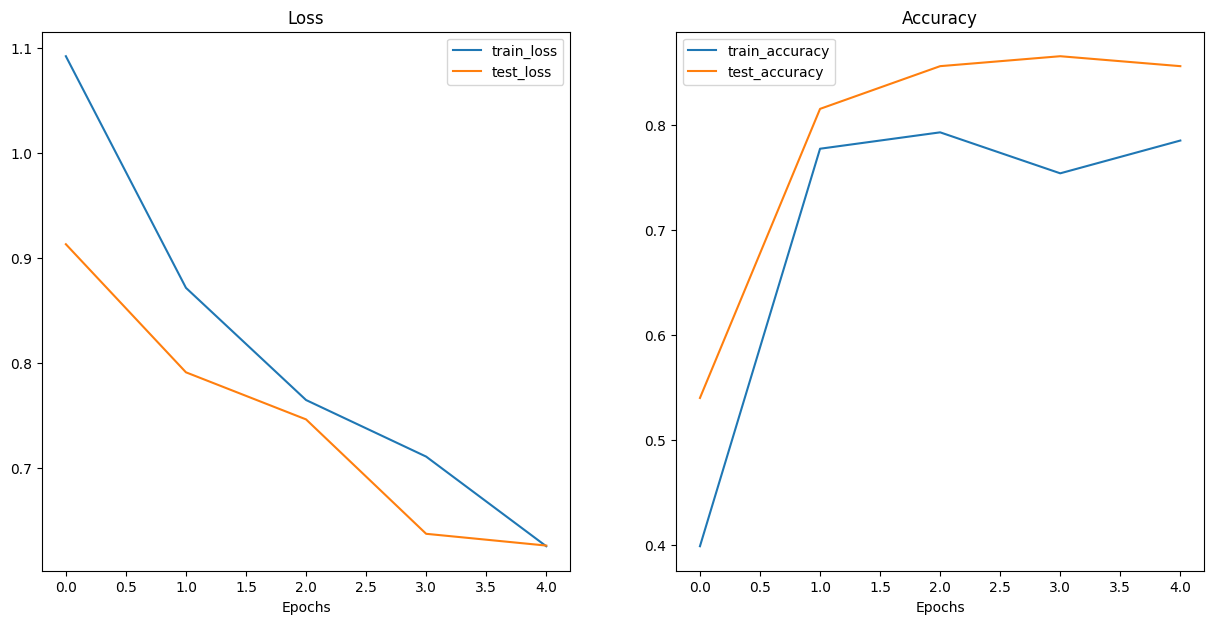

In [ ]:
try:
  from helper_functions import plot_loss_curves
except:
  print(f"[INFO] Couldn't find helper_functions.py, downloading...")
  with open("helper_functions.py", "wb") as f:
    import requests
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/helper_functions.py")
    f.write(request.content)
  from helper_functions import plot_loss_curves

# Plot the loss curves of our model
plot_loss_curves(results)

#### 1. 손실 지표 분석 (Loss Graph)

* **훈련 손실 (train_loss)**
  * 초기 1.09 부근에서 시작하여 4 에포크 시점 0.62 영역까지 일정하고 가파른 기울기로 우하향 곡선을 그립니다.
* **검증 손실 (test_loss)**
  * 훈련 손실보다 더 낮은 수치인 0.91에서 출발하여 최종 0.62 부근까지 동반 감소합니다.
* **평가**
  * 두 손실 곡선이 교차하거나 벌어지지 않고 안정적으로 내려앉는 흐름을 보아, 학습 레이트 세팅과 모델 오차 최적화가 올바르게 수행되고 있습니다.

---

#### 2. 정확도 지표 분석 (Accuracy Graph)

* **훈련 정확도 (train_accuracy)**
  * 1 에포크 만에 40%에서 77% 영역으로 급격히 상승한 후, 최종 78% 선에서 완만하게 우상향을 유지합니다.
* **검증 정확도 (test_accuracy)**
  * 초기 54%에서 빠르게 치솟아 3 에포크 시점에 최고점인 약 86%를 기록한 뒤 85% 선을 유지하며 안정화됩니다.
* **평가**
  * 단 5 에포크만의 훈련으로 85% 이상의 높은 검증 정확도를 달성한 것은 사전 훈련된 기반 레이어(features)의 특징 추출 능력이 매우 강력함을 입증합니다.

---

#### 3. 모델 종합 진단 및 향후 방향성

* **일반화 성능 검증 (과적합 없음)**
  * 훈련 데이터의 성적보다 검증 데이터의 성적(정확도)이 더 높거나 대등하게 유지되는 이상적인 패턴을 보입니다.
  * 이는 드롭아웃 레이어 및 전이 학습의 가중치 동결 메커니즘이 암기형 과적합(Overfitting)을 원천 차단하고 있음을 의미합니다.
* **추가 최적화 가능성**
  * 손실 곡선과 정확도 곡선 모두 마지막 에포크에서 완벽한 수렴(평평해지는 상태) 단계에 도달하지 않았습니다.
  * 현 상태에서 학습 에포크를 10회 이상으로 확장하거나, 동결을 일부 해제하는 파인 튜닝(Fine-tuning)을 적용할 경우 성능이 추가 향상될 여지가 높습니다.

What do our loss curves look like in terms of the ideal loss curve?

See here for more: https://www.learnpytorch.io/04_pytorch_custom_datasets/#8-what-should-an-ideal-loss-curve-look-like

## 6. Make predictions on images from the test set

Let's adhere to the data explorer's motto of *visualize, visualize, visualize*!

And make some qualitiative predictions on our test set.

Some things to keep in mind when making predictions/inference on test data/custom data.

We have to make sure that our test/custom data is:
* Same shape - images need to be same shape as model was trained on
* Same datatype - custom data should be in the same data type
* Same device - custom data/test data should be on the same device as the model
* Same transform - if you've transformed your custom data, ideally you will transform the test data and custom data the same

To do all of this automagically, let's create a function called `pred_and_plot_image()`:

The function will be similar to the one here: https://www.learnpytorch.io/04_pytorch_custom_datasets/#113-putting-custom-image-prediction-together-building-a-function

1. Take in a trained model, a list of class names, a filepath to a target image, an image size, a transform and a target device
2. Open the image with `PIL.Image.Open()`
3. Create a transform if one doesn't exist
4. Make sure the model is on the target device
5. Turn the model to `model.eval()` mode to make sure it's ready for inference (this will turn off things like `nn.Dropout()`)
6. Transform the target image and make sure its dimensionality is suited for the model (this mainly relates to batch size)
7. Make a prediction on the image by passing to the model
8. Convert the model's output logits to prediction probabilities using `torch.softmax()`
9. Convert model's prediction probabilities to prediction labels using `torch.argmax()`
10. Plot the image with `matplotlib` and set the title to the prediction label from step 9 and prediction probability from step 8

In [ ]:
from typing import List, Tuple

from PIL import Image

from torchvision import transforms

# 1. Take in a trained model...
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
  # 2. Open the image with PIL
  img = Image.open(image_path)

  # 3. Create a transform if one doesn't exist
  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
                                          transforms.Resize(image_size),
                                          transforms.ToTensor(),
                                          transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                               std=[0.229, 0.224, 0.225])
    ])

  ### Predict on image ###
  # 4. Make sure the model is on the target device
  model.to(device)

  # 5. Turn on inference mode and eval mode
  model.eval()
  with torch.inference_mode():
    # 6. Transform the image and add an extra batch dimension
    transformed_image = image_transform(img).unsqueeze(dim=0) # [batch_size, color_channels, height, width]

    # 7. Make a prediction on the transformed image by passing it to the model (also ensure it's on the target device)
    target_image_pred = model(transformed_image.to(device))

  # 8. Convert the model's output logits to pred probs
  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
  # print(target_image_pred_probs.max())

  # 9. Convert the model's pred probs to pred labels
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

  # 10. Plot image with predicted label and probability
  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
  plt.axis(False);

In [ ]:
test_dir

PosixPath('data/pizza_steak_sushi/test')

In [ ]:
class_names

['pizza', 'steak', 'sushi']

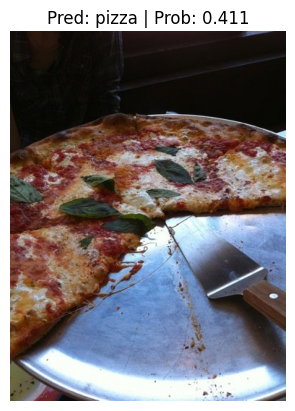

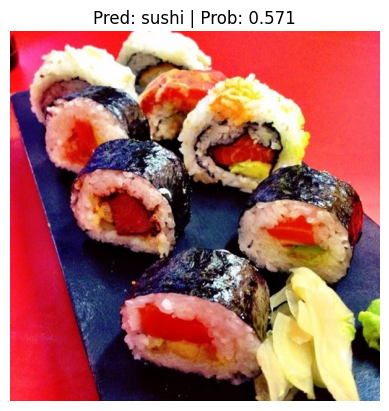

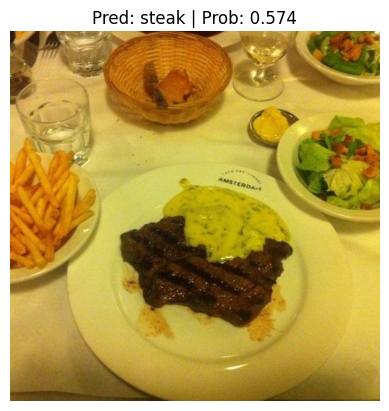

In [ ]:
# Get a random list of image paths from the test set
import random
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))
test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=num_images_to_plot)

# Make predictions on and plot the images
for image_path in test_image_path_sample:
  pred_and_plot_image(model=model,
                      image_path=image_path,
                      class_names=class_names,
                      image_size=(224, 224))

### 6.1 Making predictions on a custom image

Let's make a prediction on the pizza dad image - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/04-pizza-dad.jpeg

In [ ]:
# Download the image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't exist
if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    # Download image from GitHub with "raw" link
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/04-pizza-dad.jpeg")
    print(f"Download {custom_image_path}...")
    f.write(request.content)
else:
  print(f"{custom_image_path} already exists, skipping download...")

Download data/04-pizza-dad.jpeg...


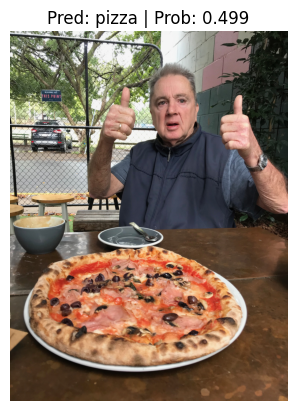

In [ ]:
# Predict on custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

## Exercises

See exercises and extra-curriculum to practice what you've learned here: https://www.learnpytorch.io/06_pytorch_transfer_learning/#exercises